# Test de corrélation linéaire et droite de regéssion
## Importations

In [1]:
import mysql.connector
from mysql.connector import Error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import importlib

if importlib.util.find_spec("sklearn") is None:
    import subprocess
    subprocess.run(["pip", "install", "scikit-learn"])

from sklearn.linear_model import LinearRegression

## Fonction

In [6]:
def scatter_plot_line(df, var1, var2, ax=None, titre=None, log=False):
    """
    Création d'un scatter plot et d'une droite de regression pour visualiser les données.
    Arguments :
        df : data frame 
        var1 : variable pour l'axe x
        var2 : variable pour l'axe y
        ax : emplacement du graphe si on fait du multi affichage
        titre : chaine de carractère pour le titre du graphe (pas obligatoire)
        log : booléen pour un affichage en échelle logarithmique

    Retourne :
        un scatter plot avec une droite de regression
        + resultat de test de corélation linéaire
    """
    if not isinstance(var1, str) or not isinstance(var2, str):
        raise TypeError("var1 et var2 doivent être des noms de colonnes (string).")

    if var1 not in df.columns or var2 not in df.columns:
        raise ValueError(f"La colonne {var1} ou {var2} n'existe pas dans le dataframe.")
    
    if df[var1].dtype not in ["int64", "float64"]:
        raise ValueError(f"La colonne {var1} n'est pas numérique.")
    
    if df[var2].dtype not in ["int64", "float64"]:
        raise ValueError(f"La colonne {var2} n'est pas numérique.")
    
            
    # Model de regression linéaire simple
    model = LinearRegression()
    model.fit(df[[var1]], df[[var2]])

    # Créer les points pour tracer la droite
    x_range = np.linspace(df[var1].min(), df[var1].max(), 100)  #crée 100 points régulièrement espacés entre le min et le max de var1
    x_range_df = pd.DataFrame(x_range, columns=[var1])  
    y_pred = model.predict(x_range_df)                          #Sklearn attend ses données en 2D (lignes x colonnes) et x_range est en 1D, donc on reshape pour le mettre au bon format

    # Calcul du coefficient de correlation linéaire
    r, p_value = stats.pearsonr(df[var1], df[var2])

    # Affichage de r carré et de la p-value
    r2 = model.score(df[[var1]], df[[var2]])
    print(f"\nR² : {r2}")
    print(f"La droite explique {r2*100:.2f}% des données.")

    # Les hypothèses
    print("Test statistique :\n - H0 : Les deux variables sont indépendantes.\n - H1 : Les deux variables sont liées.")
    print(f"p-value : {p_value:.2e}")

    if (p_value <= 0.05):
        print(f"Au risque de 5%, on rejet H0. Les variables {var1} et {var2} sont liées.")
    else:
        print(f"On a pas assez de preuve pour rejeté H0. Les deux variables {var1} et {var2} sont indépendantes.")

    if ax != None:
        ax.scatter(df[var1], df[var2])
        ax.plot(x_range, y_pred, color="red")
        ax.set_xlabel(var1)
        ax.set_ylabel(var2)
        if log:
            ax.set_xscale("log")
            ax.set_yscale("log")
        if titre != None:
            ax.set_title(titre)
        else:
            ax.set_title(var2 + " par " + var1)
        ax.grid(linestyle='--', linewidth=0.5, alpha=0.7)

    else:
        plt.scatter(df[var1], df[var2])
        plt.plot(x_range, y_pred, color="red")
        plt.xlabel(var1)
        plt.ylabel(var2)
        if log:
            plt.xscale("log")
            plt.yscale("log")
        if titre != None:
            plt.title(titre)
        else:
            plt.title(var2 + " par " + var1)
        plt.grid(linestyle='--', linewidth=0.5, alpha=0.7)
        plt.show()

## Connexion à la base de donnée

In [3]:
def getBDD():
    try:
        bdd = mysql.connector.connect(
            host='localhost',
            database='gamesale',
            user='root',
            password='',
            charset='utf8'
        )
        return bdd
    except Error as e:
        print("Erreur connexion: " + str(e))
        return None
    
bdd = getBDD()

## Création du dataframe

In [7]:
df_jeux = pd.read_sql("SELECT * FROM jeux", bdd)

# Affichage des informations
print(df_jeux.columns)
print(df_jeux.dtypes)

Index(['id_jeu', 'nom_jeu', 'annee', 'age_requis', 'nb_succes', 'nb_avis_pos',
       'nb_avis_neg', 'temps_jeu_moyen', 'prix', 'description',
       'configuration', 'ventes_AN', 'ventes_EU', 'ventes_JP', 'ventes_Autre',
       'ventes_Global'],
      dtype='str')
id_jeu               int64
nom_jeu                str
annee                  str
age_requis           int64
nb_succes            int64
nb_avis_pos          int64
nb_avis_neg          int64
temps_jeu_moyen      int64
prix               float64
description            str
configuration          str
ventes_AN              str
ventes_EU              str
ventes_JP              str
ventes_Autre           str
ventes_Global          str
dtype: object


C:\Users\Donia\AppData\Local\Temp\ipykernel_10844\958813424.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_jeux = pd.read_sql("SELECT * FROM jeux", bdd)


## Conversion des données

In [8]:
# Convertir les objets pd en numériques
list_col = ["ventes_AN","ventes_EU","ventes_JP","ventes_Autre","ventes_Global"]
for col in list_col:
    df_jeux[col] = df_jeux[col].str.replace(",", ".")
    df_jeux[col] = pd.to_numeric(df_jeux[col], errors="coerce")
print(df_jeux.dtypes)

id_jeu               int64
nom_jeu                str
annee                  str
age_requis           int64
nb_succes            int64
nb_avis_pos          int64
nb_avis_neg          int64
temps_jeu_moyen      int64
prix               float64
description            str
configuration          str
ventes_AN          float64
ventes_EU          float64
ventes_JP          float64
ventes_Autre       float64
ventes_Global      float64
dtype: object


## Heatmap
Ici comme nous traitons des données quantitatives entre elles, nous alors regarder leurs **matrice de corrélation**. Cette dernière nous donnera des informations sur les liens entre les variables.

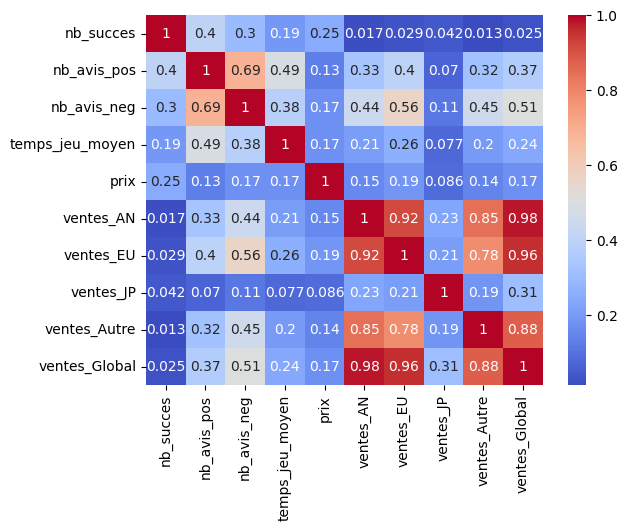

In [9]:
df_heatmap = df_jeux[["nb_succes","nb_avis_pos","nb_avis_neg","temps_jeu_moyen","prix","ventes_AN","ventes_EU","ventes_JP","ventes_Autre","ventes_Global"]]

corr = df_heatmap.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Prix et vente global
Même si on ne voit pas de lien entre les deux variables nous allons **essayé d'en trouver par d'autres moyen**. Ici par découpage.
### Toute les valeurs


R² : 0.03007608202536194
La droite explique 3.01% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 1.10e-06
Au risque de 5%, on rejet H0. Les variables prix et ventes_Global sont liées.


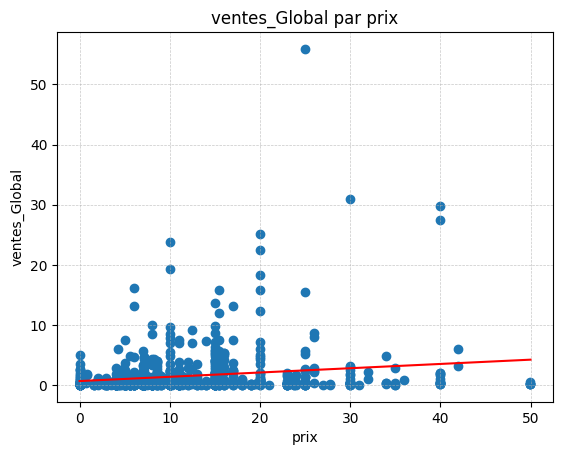

In [10]:
scatter_plot_line(df_jeux, "prix", "ventes_Global")

### Par périodes
Nous avons créer **3 périodes** :
- 1998 à 2010
- 2010 à 2015
- 2015 à 2019


R² : 0.23383519152783994
La droite explique 23.38% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 6.11e-13
Au risque de 5%, on rejet H0. Les variables prix et ventes_Global sont liées.

R² : 0.1254304646462513
La droite explique 12.54% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 7.89e-11
Au risque de 5%, on rejet H0. Les variables prix et ventes_Global sont liées.

R² : 0.006339908859813503
La droite explique 0.63% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 2.17e-01
On a pas assez de preuve pour rejeté H0. Les deux variables prix et ventes_Global sont indépendantes.


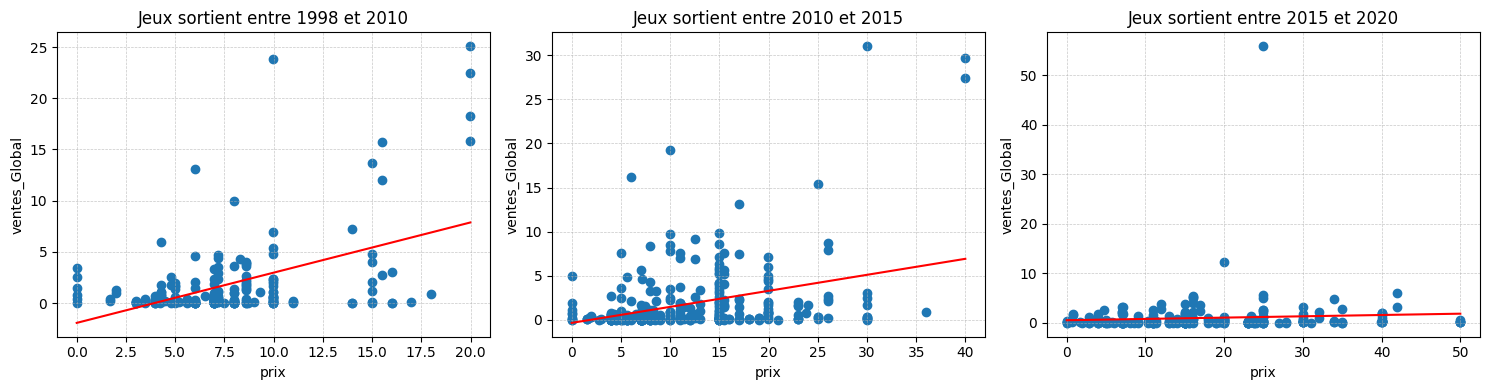

In [11]:
df_jeux["annee"] = df_jeux["annee"].replace("", np.nan)
df_jeux_annee1 = df_jeux[(df_jeux["annee"].notna()) & (df_jeux["annee"]<"2010")]
df_jeux_annee2 = df_jeux[(df_jeux["annee"]>="2010") & (df_jeux["annee"]<"2015")]
df_jeux_annee3 = df_jeux[(df_jeux["annee"]>="2015") & (df_jeux["annee"]<"2020")]

# Affichage de toutes les périodes en même temps
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter_plot_line(df_jeux_annee1, "prix", "ventes_Global", axes[0], "Jeux sortient entre 1998 et 2010")
scatter_plot_line(df_jeux_annee2, "prix", "ventes_Global", axes[1], "Jeux sortient entre 2010 et 2015")
scatter_plot_line(df_jeux_annee3, "prix", "ventes_Global", axes[2], "Jeux sortient entre 2015 et 2020")

plt.tight_layout()
plt.show()

### Par année seulement

C:\Users\Donia\AppData\Local\Temp\ipykernel_10844\3777641874.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p_value = stats.pearsonr(df[var1], df[var2])



R² : 0.0
La droite explique 0.00% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : nan
On a pas assez de preuve pour rejeté H0. Les deux variables prix et ventes_Global sont indépendantes.

R² : 0.528502861176132
La droite explique 52.85% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 1.72e-02
Au risque de 5%, on rejet H0. Les variables prix et ventes_Global sont liées.

R² : 0.451543500749387
La droite explique 45.15% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 3.48e-05
Au risque de 5%, on rejet H0. Les variables prix et ventes_Global sont liées.

R² : 0.2189229824623471
La droite explique 21.89% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 2.43e-04
Au risque de 

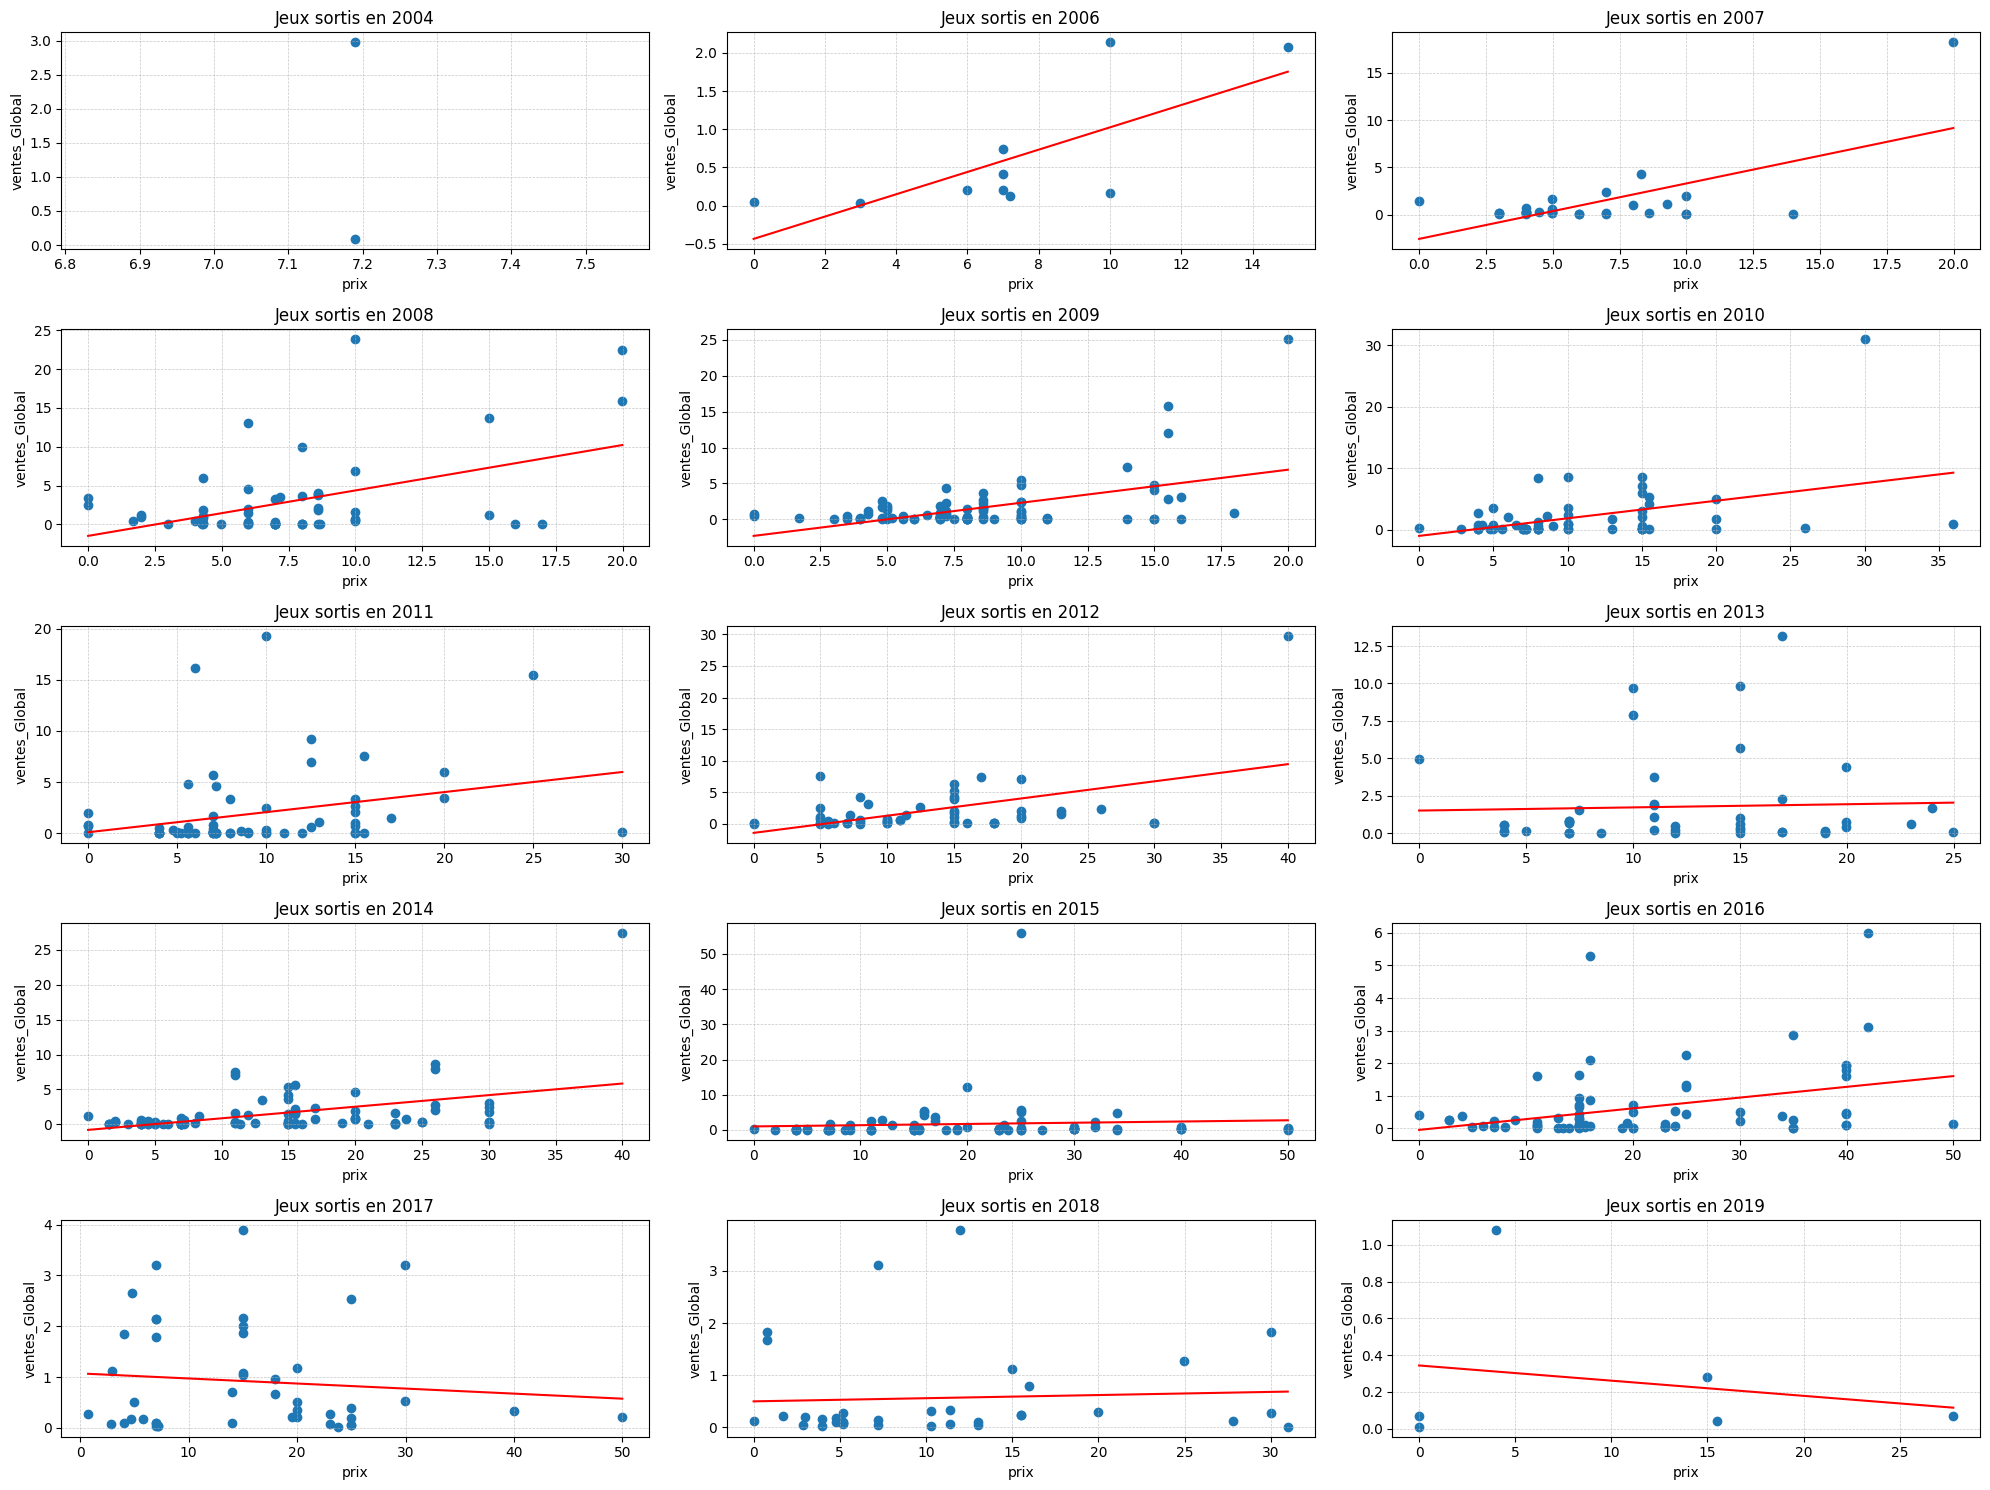

In [12]:
# Création d'une liste contenant toutes les années cité dans jeu de données
annees = sorted(df_jeux["annee"].dropna().unique())

# On supprime les années où il y a moins de deux observations différentes
# Choix fait à partir de requêtes SQL
annees.remove("1998")
annees.remove("2000")
annees.remove("2002")
annees.remove("2005")

len(annees)

# Affichage
fig, axes = plt.subplots(5, 3, figsize=(20, 15))
axes = axes.flatten()   # transforme la grille en liste simple

for i, annee in enumerate(annees):
    df_temp = df_jeux[df_jeux["annee"] == annee]
    
    scatter_plot_line(
        df_temp,
        "prix",
        "ventes_Global",
        axes[i],
        f"Jeux sortis en {int(annee)}"
    )

plt.tight_layout()
plt.show()

### Par restriction d'âge
Dans cette partie nous allons **seulement regarder les jeux avec leur restriction, et pas plus**. Par exemple, pour les jeux 16 ans et plus, nous allons seulemnt regarder les jeux avec écrit 16 ans, nous n'allons pas ajouter à cela les jeux tout âges et autre.
- Tout âge
- 12 ans
- 16 ans
- 18 ans

c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



R² : 0.013650997700660472
La droite explique 1.37% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 2.51e-03
Au risque de 5%, on rejet H0. Les variables prix et ventes_Global sont liées.

R² : 0.3195257074873903
La droite explique 31.95% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 7.00e-02
On a pas assez de preuve pour rejeté H0. Les deux variables prix et ventes_Global sont indépendantes.

R² : 0.08946951693323191
La droite explique 8.95% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 6.08e-02
On a pas assez de preuve pour rejeté H0. Les deux variables prix et ventes_Global sont indépendantes.

R² : 0.04774410777212268
La droite explique 4.77% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variab

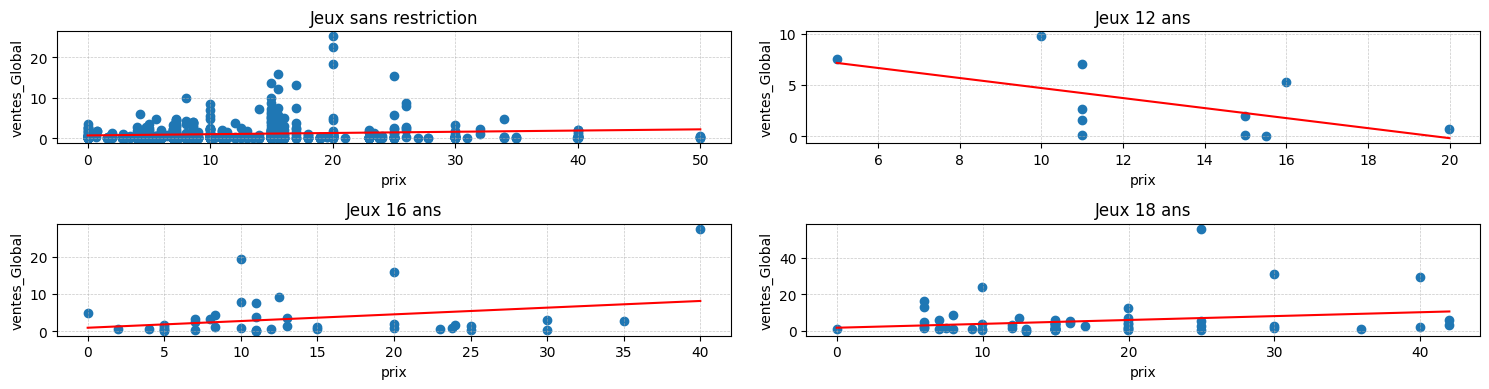

In [15]:
df_jeux_age1 = df_jeux[(df_jeux["age_requis"].notna()) & (df_jeux["age_requis"]<=10)]
df_jeux_age2 = df_jeux[df_jeux["age_requis"] == 12]
df_jeux_age3 = df_jeux[df_jeux["age_requis"] == 16]
df_jeux_age4 = df_jeux[df_jeux["age_requis"] == 18]

# Affichages
fig, axes = plt.subplots(2, 2, figsize=(15, 4))

scatter_plot_line(df_jeux_age1, "prix", "ventes_Global", axes[0,0], "Jeux sans restriction")
scatter_plot_line(df_jeux_age2, "prix", "ventes_Global", axes[0,1], "Jeux 12 ans")
scatter_plot_line(df_jeux_age3, "prix", "ventes_Global", axes[1,0], "Jeux 16 ans")
scatter_plot_line(df_jeux_age4, "prix", "ventes_Global", axes[1,1], "Jeux 18 ans")

plt.tight_layout()
plt.show()

## Nombre d'avis positifs par vente global
### Affichage simple


R² : 0.13387592412988036
La droite explique 13.39% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 4.06e-26
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.


c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


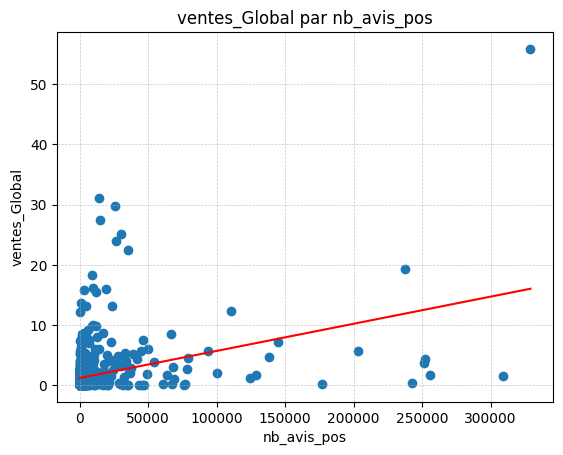

In [16]:
scatter_plot_line(df_jeux, "nb_avis_pos", "ventes_Global")

### Affichage avec une échelle logarithmique
Comme on "zoom" sur les données, il est normal que la droite de régression ne s'affiche plus comme une droite.

c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



R² : 0.13387592412988036
La droite explique 13.39% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 4.06e-26
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.


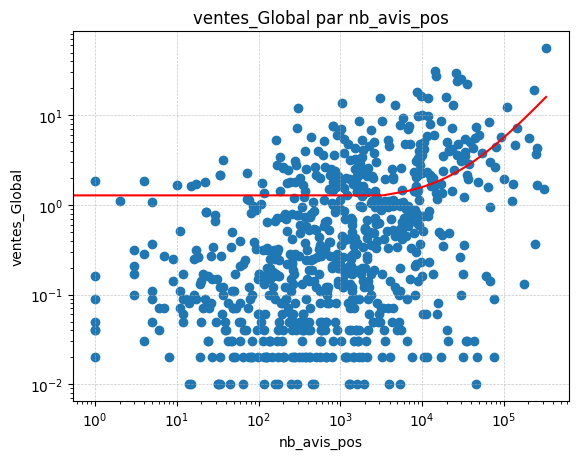

In [17]:
scatter_plot_line(df_jeux, "nb_avis_pos", "ventes_Global", log=True)

### Par période

c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



R² : 0.03442456672488303
La droite explique 3.44% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 9.05e-03
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.

R² : 0.04868723006079412
La droite explique 4.87% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 7.24e-05
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.

R² : 0.43203412093488536
La droite explique 43.20% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 2.57e-31
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.


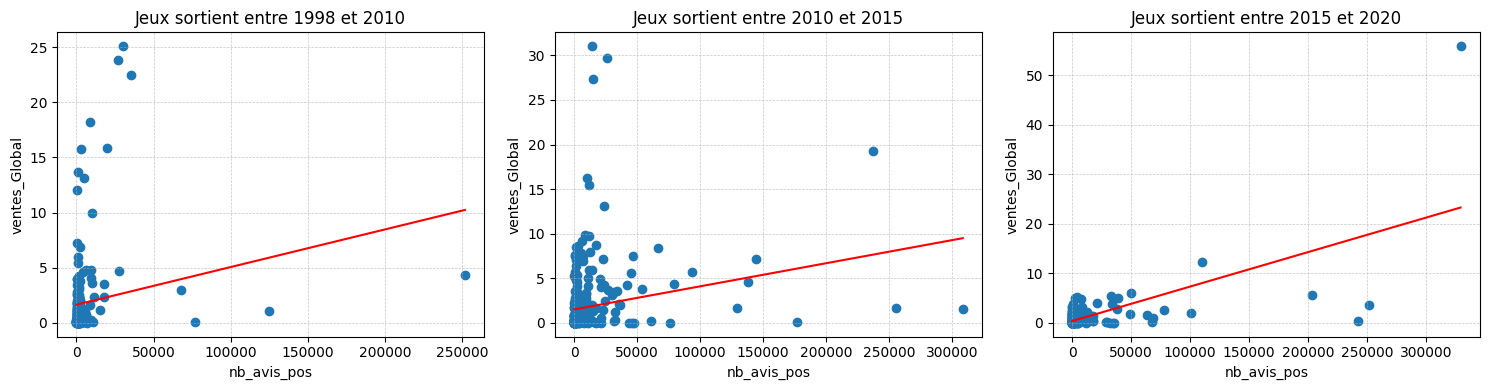

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter_plot_line(df_jeux_annee1, "nb_avis_pos", "ventes_Global", axes[0], "Jeux sortient entre 1998 et 2010")
scatter_plot_line(df_jeux_annee2, "nb_avis_pos", "ventes_Global", axes[1], "Jeux sortient entre 2010 et 2015")
scatter_plot_line(df_jeux_annee3, "nb_avis_pos", "ventes_Global", axes[2], "Jeux sortient entre 2015 et 2020")

plt.tight_layout()
plt.show()

### Par année

c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\minic


R² : 1.0
La droite explique 100.00% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 1.00e+00
On a pas assez de preuve pour rejeté H0. Les deux variables nb_avis_pos et ventes_Global sont indépendantes.

R² : 0.02568000863030917
La droite explique 2.57% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 6.58e-01
On a pas assez de preuve pour rejeté H0. Les deux variables nb_avis_pos et ventes_Global sont indépendantes.

R² : 0.2696188060717025
La droite explique 26.96% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 2.76e-03
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.

R² : 0.5845555828013298
La droite explique 58.46% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux 

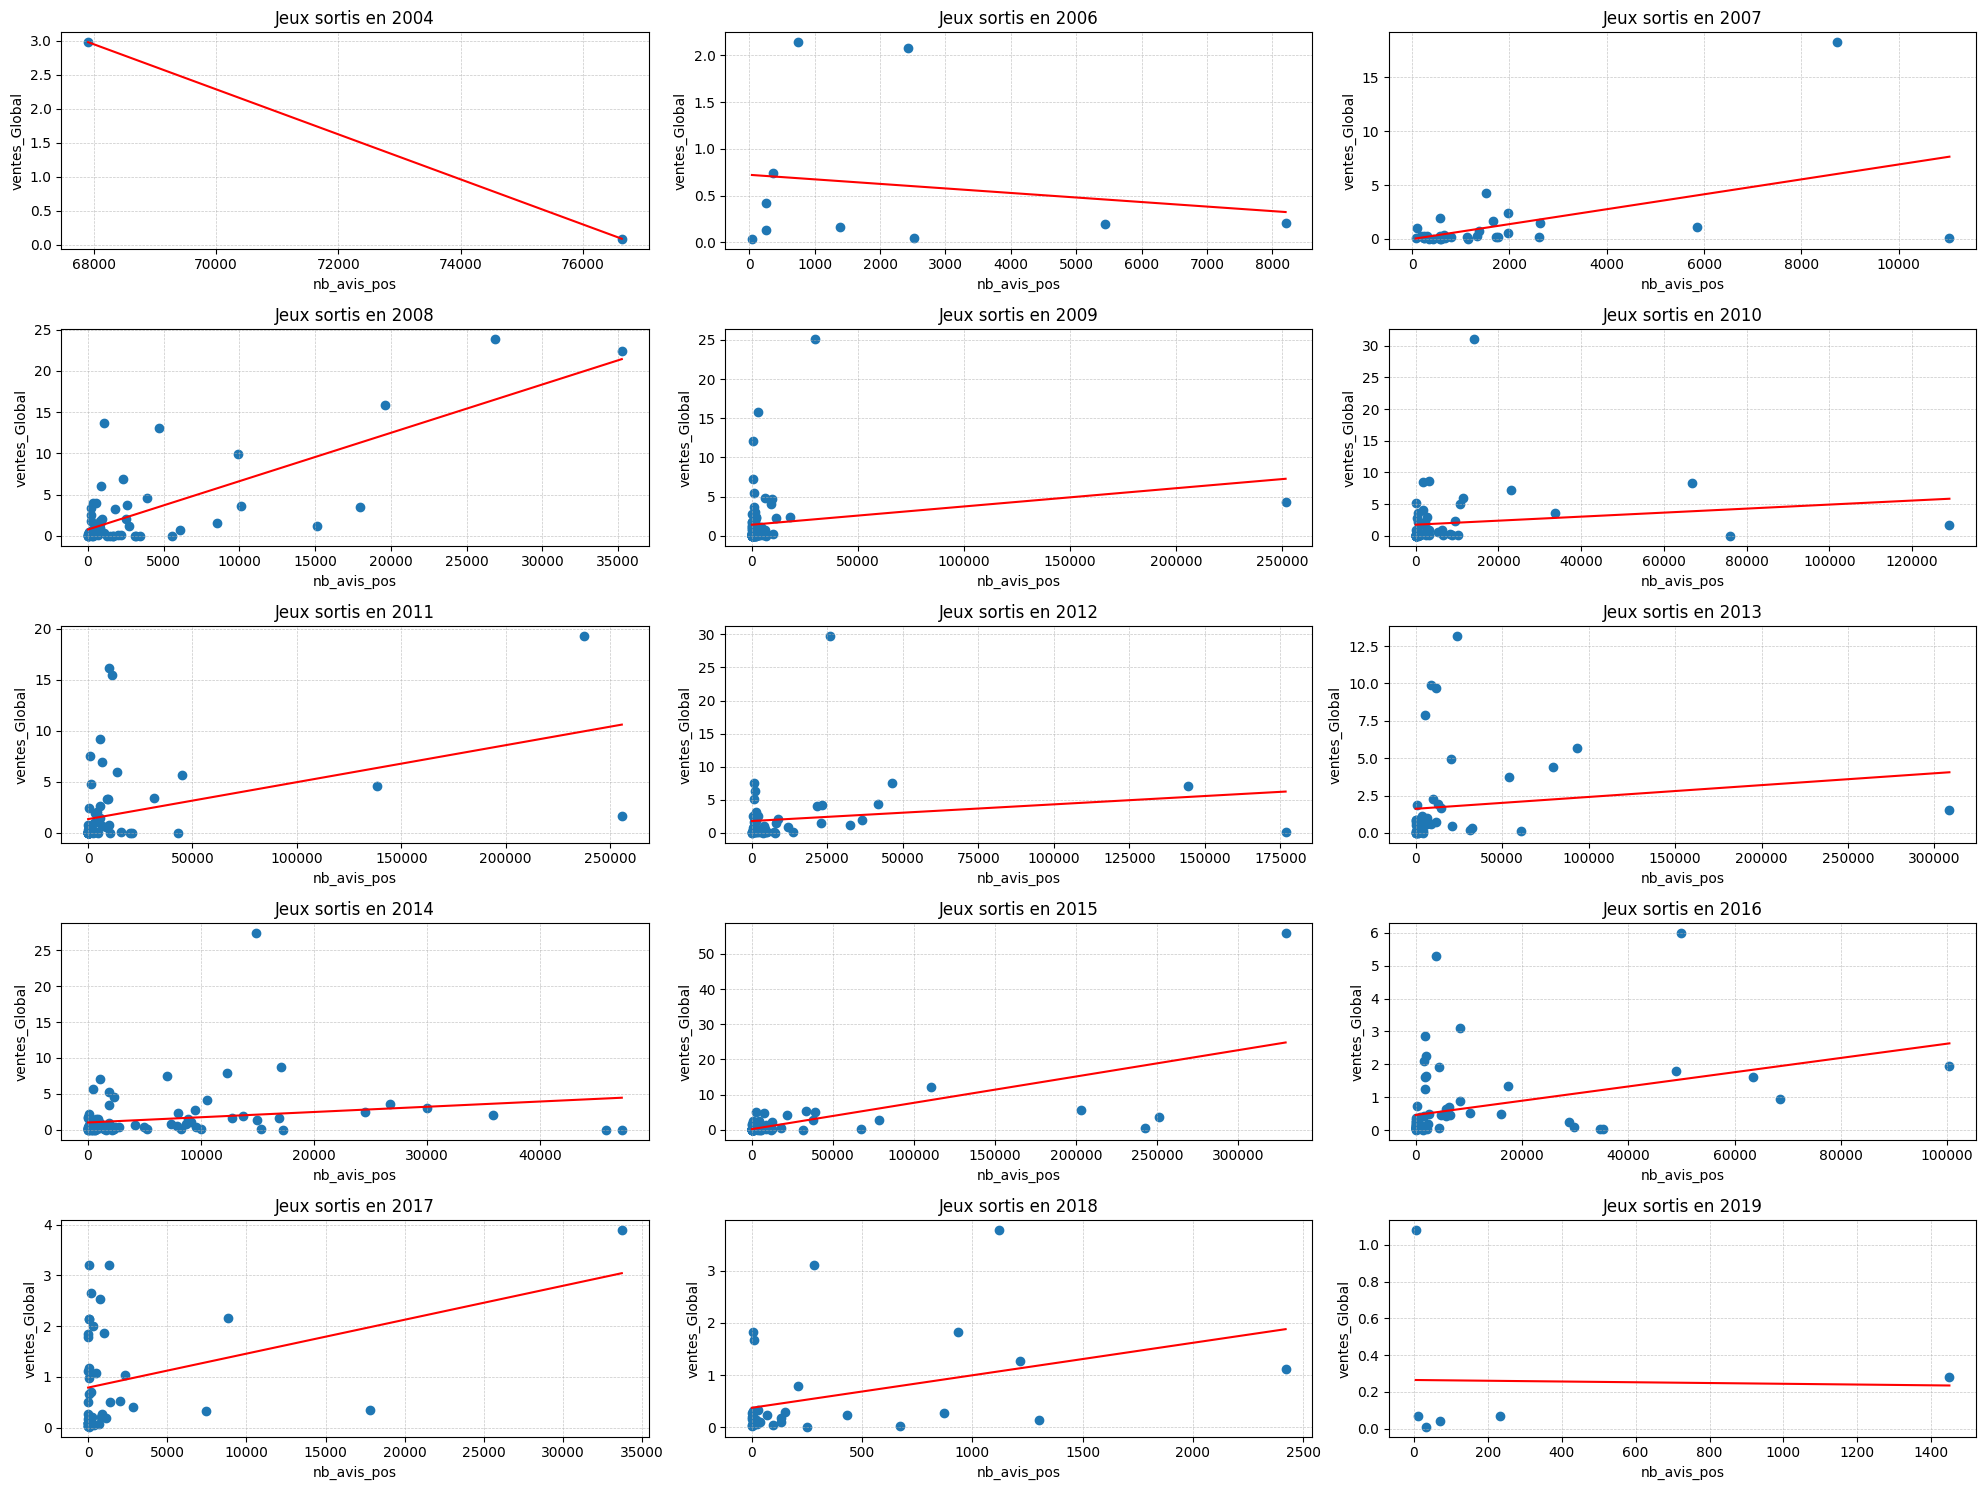

In [20]:
fig, axes = plt.subplots(5, 3, figsize=(20, 15))
axes = axes.flatten()

for i, annee in enumerate(annees):
    df_temp = df_jeux[df_jeux["annee"] == annee]
    
    scatter_plot_line(
        df_temp,
        "nb_avis_pos",
        "ventes_Global",
        axes[i],
        f"Jeux sortis en {int(annee)}"
    )

plt.tight_layout()
plt.show()

### Par restriction d'âge

c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



R² : 0.02263170054560626
La droite explique 2.26% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 9.61e-05
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.

R² : 1.430746095965052e-05
La droite explique 0.00% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 9.91e-01
On a pas assez de preuve pour rejeté H0. Les deux variables nb_avis_pos et ventes_Global sont indépendantes.

R² : 0.258357895711936
La droite explique 25.84% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 8.12e-04
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et ventes_Global sont liées.

R² : 0.24577911307769262
La droite explique 24.58% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variable

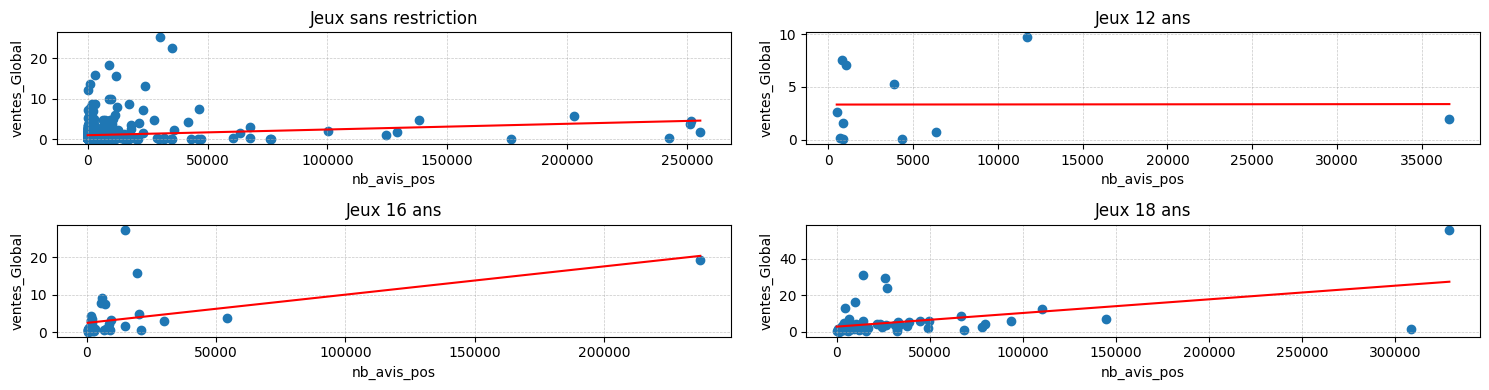

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 4))

scatter_plot_line(df_jeux_age1, "nb_avis_pos", "ventes_Global", axes[0,0], "Jeux sans restriction")
scatter_plot_line(df_jeux_age2, "nb_avis_pos", "ventes_Global", axes[0,1], "Jeux 12 ans")
scatter_plot_line(df_jeux_age3, "nb_avis_pos", "ventes_Global", axes[1,0], "Jeux 16 ans")
scatter_plot_line(df_jeux_age4, "nb_avis_pos", "ventes_Global", axes[1,1], "Jeux 18 ans")

plt.tight_layout()
plt.show()

## Nombre d'avis positifs par nombre d'avis négatifs
### Affichage simple


R² : 0.47548756183786245
La droite explique 47.55% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 4.00e-111
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et nb_avis_neg sont liées.


c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


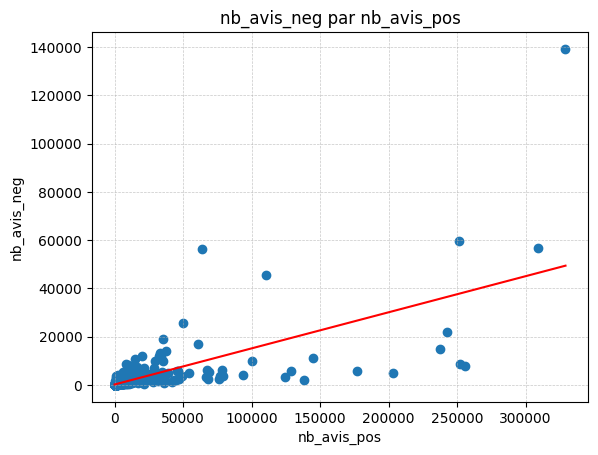

In [23]:
scatter_plot_line(df_jeux, "nb_avis_pos", "nb_avis_neg")

### Affichage avec un échelle logarithime
Encore une fois il est normal que la droite de régression ne s'affiche pas "correctement".

c:\Users\Donia\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



R² : 0.47548756183786245
La droite explique 47.55% des données.
Test statistique :
 - H0 : Les deux variables sont indépendantes.
 - H1 : Les deux variables sont liées.
p-value : 4.00e-111
Au risque de 5%, on rejet H0. Les variables nb_avis_pos et nb_avis_neg sont liées.


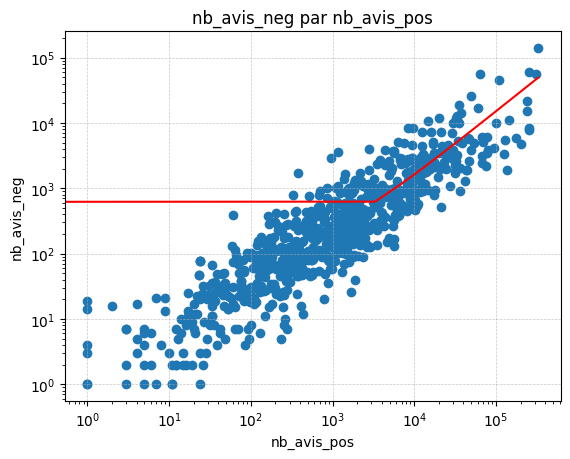

In [22]:
scatter_plot_line(df_jeux, "nb_avis_pos", "nb_avis_neg", log=True)